# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [50]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [51]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [52]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

In [ ]:
# 1. Número de atributos:
print("Número de atributos:", len(diabetes['feature_names']))
print("   Atributos:", diabetes['feature_names'])
# Hay 10 atributos: age, sex, bmi, bp, s1, s2, s3, s4, s5, s6, que son variables clínicas de pacientes diabéticos (edad, sexo, IMC, presión arterial y mediciones de suero sanguíneo)

Número de atributos: 10
   Atributos: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [54]:
# 2. ¿Cuál es la relación entre diabetes['data'] y diabetes['target']?
print("   - diabetes['data'] → variables independientes (X),   shape:", diabetes['data'].shape)
print("   - diabetes['target'] → variable objetivo (y),   shape:", diabetes['target'].shape)
# diabetes['data'] contiene las características de los pacientes, mientras que diabetes['target'] contiene la variable objetivo, 
# data es la variable predictora (x) y target es la variable a predecir (y)

   - diabetes['data'] → variables independientes (X),   shape: (442, 10)
   - diabetes['target'] → variable objetivo (y),   shape: (442,)


In [55]:
# 3. Número de registros:
print("\n3. Número de registros:", diabetes['data'].shape[0])
# Hay 442 registros o pacientes en el dataset.


3. Número de registros: 442


#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [56]:
print("Shape data:  ", diabetes['data'].shape)
print("Shape target:", diabetes['target'].shape)
# La salida es la que se espera, ya que el número de registros (442) coincide en ambas partes del dataset, y el número de atributos (10) 
# corresponde a las características clínicas de los pacientes.

Shape data:   (442, 10)
Shape target: (442,)


## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [57]:
from sklearn.linear_model import LinearRegression

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [58]:
diabetes_model = LinearRegression()


#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [59]:
diabetes_data_train   = diabetes['data'][:-20]
diabetes_target_train = diabetes['target'][:-20]
diabetes_data_test    = diabetes['data'][-20:]
diabetes_target_test  = diabetes['target'][-20:]

Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [60]:
# Transformamos la matriz de datos en un DataFrame de pandas:
diabetes = pd.DataFrame(diabetes['data'], columns=diabetes['feature_names'])
diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [61]:
# Análisis descriptivo
diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


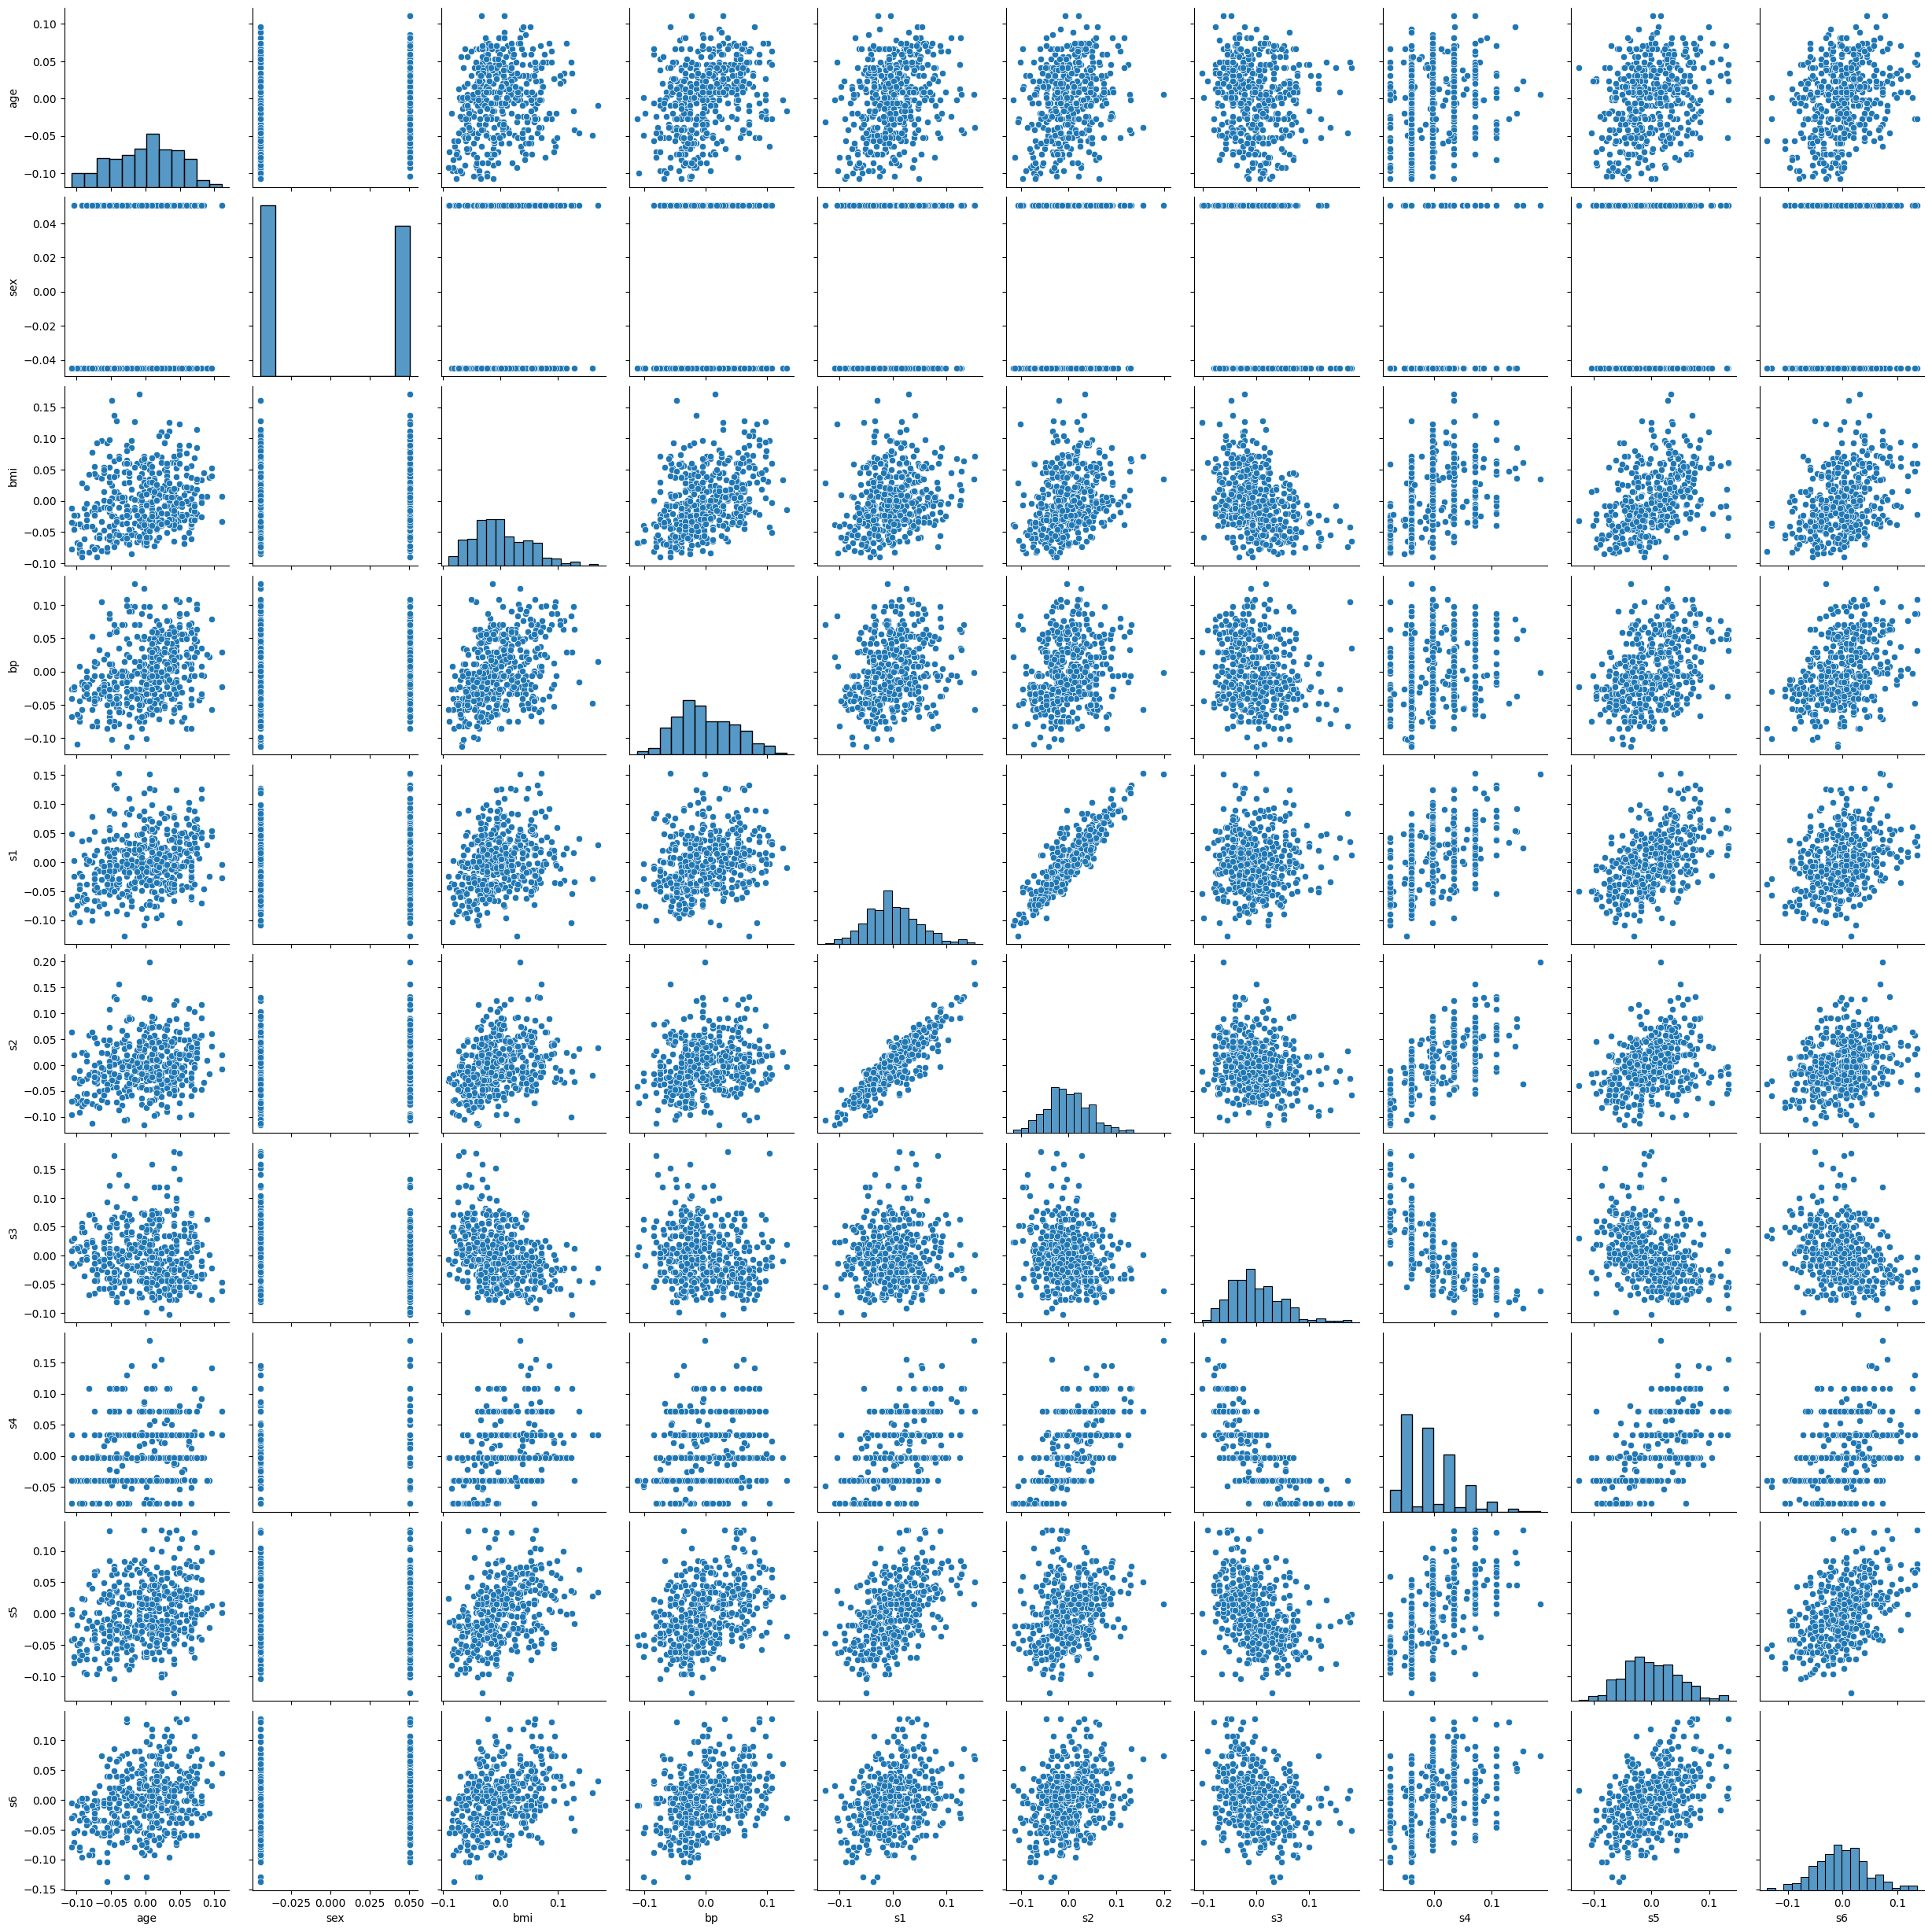

In [62]:
sns.pairplot(diabetes);

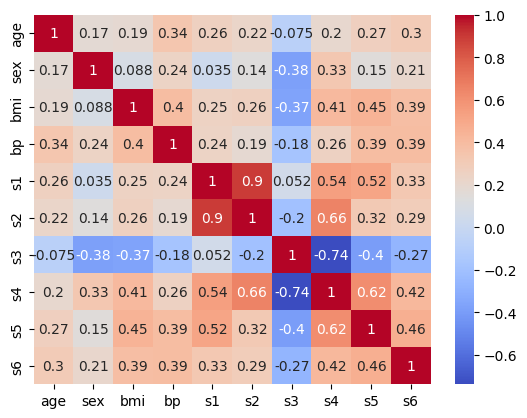

In [78]:
sns.heatmap(diabetes.corr(), annot=True, cmap='coolwarm');

In [63]:
diabetes.corr(numeric_only=True)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


In [64]:
# Entrenar el modelo:
diabetes_model.fit(diabetes_data_train, diabetes_target_train)
# Imprimir Intercept y coeficientes:
print("Intercept:", diabetes_model.intercept_)
feature_names = ['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6']
print("Coefficients:")
coeff_df = pd.DataFrame(diabetes_model.coef_,
                        diabetes.columns,
                        columns=['Coefficient'])
coeff_df

Intercept: 152.76429169049118
Coefficients:


,Coefficient
age,0.306094
sex,-237.635570
bmi,510.538048
bp,327.729878
s1,-814.111926
s2,492.799595
s3,102.841240
s4,184.603496
s5,743.509388
s6,76.096646


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [65]:
# Predicciones:
predictions = diabetes_model.predict(diabetes_data_test)
print("Predicciones:", predictions)

Predicciones: [197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]


#### Print your `diabetes_target_test` and compare with the prediction. 

In [73]:
predictions = diabetes_model.predict(diabetes_data_test)

print("Real      vs   Predicción")
print("-" * 35)
for real, pred in zip(diabetes_target_test, predictions):
    print(f"{real:>8.1f}  →  {pred:>10.2f}")

Real      vs   Predicción
-----------------------------------
   233.0  →      197.62
    91.0  →      155.44
   111.0  →      172.89
   152.0  →      111.53
   120.0  →      164.79
    67.0  →      131.07
   310.0  →      259.12
    94.0  →      100.48
   183.0  →      117.06
    66.0  →      124.30
   173.0  →      218.37
    72.0  →       61.20
    49.0  →      132.25
    64.0  →      120.33
    48.0  →       52.55
   178.0  →      194.04
   104.0  →      102.58
   132.0  →      123.57
   220.0  →      211.03
    57.0  →       52.60


#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [66]:
import numpy as np
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(diabetes_target_test, predictions))
print('MSE:', metrics.mean_squared_error(diabetes_target_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(diabetes_target_test, predictions)))


print("¿Son exactamente iguales?", np.allclose(diabetes_target_test, predictions))
# No son exactamente iguales. El modelo comete errores


MAE: 36.60961865545879
MSE: 2004.5186863342096
RMSE: 44.77185149549
¿Son exactamente iguales? False


#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [67]:
from sklearn import preprocessing

std_scale = preprocessing.StandardScaler()
std_scale.fit(diabetes_data_train)
X_train_scal = std_scale.transform(diabetes_data_train)
X_test_scal = std_scale.transform(diabetes_data_test)

lm_scal = LinearRegression()
lm_scal.fit(X_train_scal, diabetes_target_train)

predictions_2 = lm_scal.predict(X_test_scal)

intercept_scal = lm_scal.intercept_
features_std = pd.DataFrame(lm_scal.coef_, diabetes.columns, columns=['coefficient'])

features_std.sort_values('coefficient', ascending=False)

,coefficient
s5,35.644497
bmi,24.295677
s2,23.384473
bp,15.598870
s4,8.799364
s3,4.817996
s6,3.606619
age,0.014631
sex,-11.300962
s1,-38.634072


In [68]:
print('MAE:', metrics.mean_absolute_error(diabetes_target_test, predictions))
print('MSE:', metrics.mean_squared_error(diabetes_target_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(diabetes_target_test, predictions)))

MAE: 36.60961865545879
MSE: 2004.5186863342096
RMSE: 44.77185149549


In [ ]:
# Esta ultima parte no se si la he hecho bien la verdad. Pero los errores son exactamente iguales a los que teníamos antes, lo que me hace pensar que 
# efectivamente está mal hecho.
# Sería por tanto igual necesario disminuir el número de variables para mejorar el modelo.

In [71]:
# Solo las 3 features más correlacionadas: bmi(2), s5(8), bp(3)
best_idx = [2, 3, 8]

X_train_best = diabetes_data_train[:, best_idx]
X_test_best  = diabetes_data_test[:, best_idx]
lm_best = LinearRegression()
lm_best.fit(X_train_best, diabetes_target_train)
predictions_best = lm_best.predict(X_test_best)
print("Predicciones:", predictions_best)

Predicciones: [235.6182698  145.34574172 167.15328526  95.63199044 163.27806123
 130.37712905 265.00380439 112.95337086  99.91581287 132.2588779
 214.28880334  81.31424024 131.52651238 107.3848938   62.09658569
 197.57923059 115.35855717 122.91664719 200.4949372   84.91276394]


In [70]:
# Imprimir errores:
print('MAE:', metrics.mean_absolute_error(diabetes_target_test, predictions_best))
print('MSE:', metrics.mean_squared_error(diabetes_target_test, predictions_best))
print('RMSE:', np.sqrt(metrics.mean_squared_error(diabetes_target_test, predictions_best)))

MAE: 38.374156544210386
MSE: 2064.7583763657613
RMSE: 45.439612414343515
